In [5]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [19]:
X_train = pd.read_csv(r"C:\Users\VIDWAN\Venlix\data\X_train.csv")
X_test = pd.read_csv(r"C:\Users\VIDWAN\Venlix\data\X_test.csv")

y_train = pd.read_csv(r"C:\Users\VIDWAN\Venlix\data\y_train.csv").squeeze()
y_test = pd.read_csv(r"C:\Users\VIDWAN\Venlix\data\y_test.csv").squeeze()

In [20]:
def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))

    print("\nClassification Report\n")
    print(classification_report(y_test, pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, pred))

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

evaluate_model(lr, X_test, y_test)

LogisticRegression
Accuracy : 0.925811614083219
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      8099
           1       0.00      0.00      0.00       649

    accuracy                           0.93      8748
   macro avg       0.46      0.50      0.48      8748
weighted avg       0.86      0.93      0.89      8748


Confusion Matrix

[[8099    0]
 [ 649    0]]


C:\Users\VIDWAN\anaconda3\envs\attend\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\VIDWAN\anaconda3\envs\attend\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VIDWAN\anaconda3\envs\attend\lib\site-packages\sklearn\metr

In [22]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test)

DecisionTreeClassifier
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8099
           1       1.00      1.00      1.00       649

    accuracy                           1.00      8748
   macro avg       1.00      1.00      1.00      8748
weighted avg       1.00      1.00      1.00      8748


Confusion Matrix

[[8099    0]
 [   0  649]]


In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test)

RandomForestClassifier
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8099
           1       1.00      1.00      1.00       649

    accuracy                           1.00      8748
   macro avg       1.00      1.00      1.00      8748
weighted avg       1.00      1.00      1.00      8748


Confusion Matrix

[[8099    0]
 [   0  649]]


In [24]:
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(scale_pos_weight)

12.489205859676176


In [25]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    scale_pos_weight=scale_pos_weight,

    eval_metric="logloss"

)

xgb.fit(X_train, y_train)

evaluate_model(xgb, X_test, y_test)

XGBClassifier
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8099
           1       1.00      1.00      1.00       649

    accuracy                           1.00      8748
   macro avg       1.00      1.00      1.00      8748
weighted avg       1.00      1.00      1.00      8748


Confusion Matrix

[[8099    0]
 [   0  649]]


In [26]:
lgbm = LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    class_weight="balanced"

)

lgbm.fit(X_train, y_train)

evaluate_model(lgbm, X_test, y_test)

[LightGBM] [Info] Number of positive: 2594, number of negative: 32397
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1858
[LightGBM] [Info] Number of data points in the train set: 34991, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [27]:
models = {

    "Logistic Regression": lr,

    "Decision Tree": dt,

    "Random Forest": rf,

    "XGBoost": xgb,

    "LightGBM": lgbm

}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(y_test, pred),

        "Recall": recall_score(y_test, pred),

        "F1 Score": f1_score(y_test, pred)

    })

results = pd.DataFrame(results)

results.sort_values(
    "F1 Score",
    ascending=False
)

C:\Users\VIDWAN\anaconda3\envs\attend\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.000000,1.0,1.0,1.0
3,XGBoost,1.000000,1.0,1.0,1.0
2,Random Forest,1.000000,1.0,1.0,1.0
4,LightGBM,1.000000,1.0,1.0,1.0
0,Logistic Regression,0.925812,0.0,0.0,0.0


In [28]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
19,risk_score,0.709035
14,customer_unavailability_history,0.076593
13,driver_on_time_rate,0.065861
6,Weather,0.041429
18,distance_km,0.040049
24,hour_of_day,0.026109
4,Drop_Latitude,0.013613
7,Traffic,0.010846
15,address_failure_history_rate,0.008121
10,Delivery_Time,0.002092


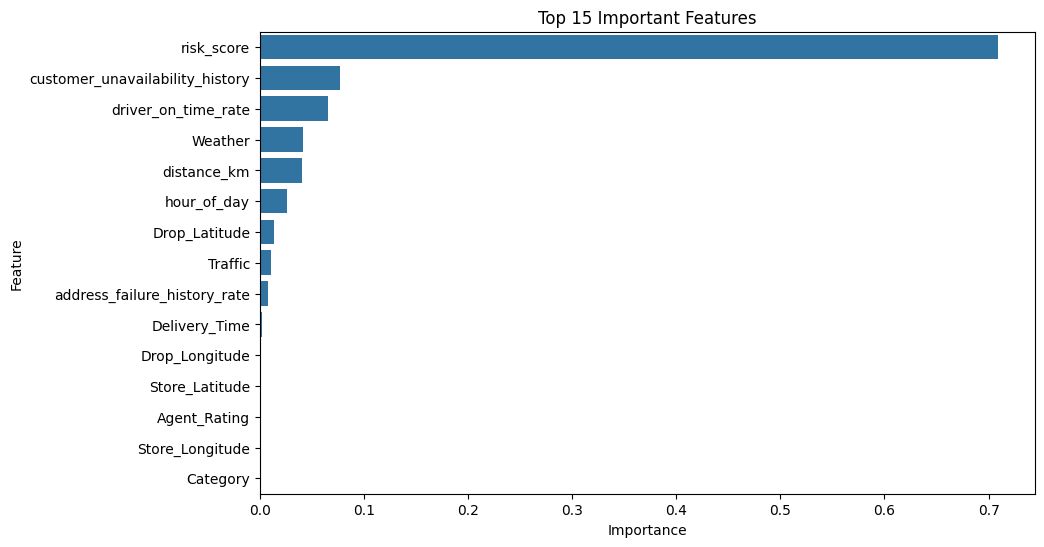

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [30]:
import joblib

joblib.dump(xgb, "venlix_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [42]:
import joblib

feature_columns = list(X_train.columns)

joblib.dump(feature_columns, "feature_columns.pkl")

print("Saved successfully!")

Saved successfully!


In [44]:
import pandas as pd

X_train = pd.read_csv(r"C:\Users\VIDWAN\Venlix\data\X_train.csv")

In [46]:
joblib.dump(list(X_train.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [49]:
import joblib

joblib.dump(
    list(X_train.columns),
    r"C:\Users\VIDWAN\Venlix\backend\models\feature_columns.pkl"
)

print("✅ feature_columns.pkl saved successfully!")

✅ feature_columns.pkl saved successfully!
